# Psychoacoustic vs. Neural Audio Codecs
Comparative analysis of traditional psychoacoustic codecs (MP3, AAC) and neural audio codecs (Meta EnCodec).

---

## Setup
Install system dependencies and Python libraries.

In [1]:
!sudo apt update && sudo apt install -y ffmpeg
!pip install torch torchaudio pydub encodec numpy scipy matplotlib librosa soundfile

Hit:1 https://packages.microsoft.com/repos/microsoft-ubuntu-noble-prod noble InRelease
Hit:2 https://repo.anaconda.com/pkgs/misc/debrepo/conda stable InRelease
Get:3 https://dl.yarnpkg.com/debian stable InReleasem
Err:3 https://dl.yarnpkg.com/debian stable InRelease
  The following signatures couldn't be verified because the public key is not available: NO_PUBKEY 62D54FD4003F6525
Hit:4 http://archive.ubuntu.com/ubuntu noble InRelease                   
Hit:5 http://security.ubuntu.com/ubuntu noble-security InRelease
Hit:6 http://archive.ubuntu.com/ubuntu noble-updates InRelease
Hit:7 http://archive.ubuntu.com/ubuntu noble-backports InRelease
Reading package lists... Done
W: GPG error: https://dl.yarnpkg.com/debian stable InRelease: The following signatures couldn't be verified because the public key is not available: NO_PUBKEY 62D54FD4003F6525
E: The repository 'https://dl.yarnpkg.com/debian stable InRelease' is not signed.
N: Updating from such a repository can't be done securely, and

## Upload Source Audio
Upload your `.flac` source audio files into `source-audio/` folder.

Run the cell below to create the required directories and verify your files are in place.

In [3]:
import os

os.makedirs("source-audio", exist_ok=True)
os.makedirs("export-output/traditional-coding", exist_ok=True)
os.makedirs("export-output/neural-coding", exist_ok=True)
os.makedirs("export-output/plots", exist_ok=True)

print("Directories created.")
print("\nFiles in source-audio/:")
for f in sorted(os.listdir("source-audio")):
    print(f"  {f}")

if not os.listdir("source-audio"):
    print("  (empty) -- Please upload your .flac files here before continuing.")

Directories created.

Files in source-audio/:
  27.flac
  49.flac
  69.flac


---

## Step 1: Traditional Codec Sweep (MP3 & AAC)
Encodes source audio to MP3 and AAC at 5 bitrates (8k, 12k, 24k, 48k, 64k), then decodes back to WAV.

In [4]:
import os
from pydub import AudioSegment

def compress_traditional_sweep(input_wav, track_name, bitrates=["8k", "12k", "24k", "48k", "64k"]):
    """
    Compresses a WAV file to MP3 and AAC across 5 bitrates,
    then decodes them back to WAV for mathematical analysis.
    """
    print("--- Processing Traditional Codecs ---")
    audio = AudioSegment.from_file(input_wav)
    recon_files = {"mp3": {}, "aac": {}}

    # Ensure per-track output subdirectory exists
    track_dir = f"export-output/traditional-coding/{track_name}_trad"
    os.makedirs(track_dir, exist_ok=True)

    for br in bitrates:
        print(f"Encoding at {br}bps...")

        # MP3 Processing
        mp3_path = f"{track_dir}/temp_{br}.mp3"
        mp3_recon = f"{track_dir}/recon_{track_name}_mp3_{br}.wav"
        audio.export(mp3_path, format="mp3", bitrate=br)
        AudioSegment.from_mp3(mp3_path).export(mp3_recon, format="wav")
        recon_files["mp3"][br] = mp3_recon

        # AAC Processing (requires ffmpeg installed on OS)
        aac_path = f"{track_dir}/temp_{br}.aac"
        aac_recon = f"{track_dir}/recon_{track_name}_aac_{br}.wav"
        audio.export(aac_path, format="adts", bitrate=br)
        AudioSegment.from_file(aac_path, format="aac").export(aac_recon, format="wav")
        recon_files["aac"][br] = aac_recon

        # Clean up the compressed files to save disk space
        os.remove(mp3_path)
        os.remove(aac_path)

    print("Traditional compression sweep complete.\n")
    return recon_files

In [5]:
# Run for all tracks
trad_files = compress_traditional_sweep("source-audio/27.flac", "track-27")
print(trad_files)

trad_files = compress_traditional_sweep("source-audio/49.flac", "track-49")
print(trad_files)

trad_files = compress_traditional_sweep("source-audio/69.flac", "track-69")
print(trad_files)

--- Processing Traditional Codecs ---
Encoding at 8kbps...
Encoding at 12kbps...
Encoding at 24kbps...
Encoding at 48kbps...
Encoding at 64kbps...
Traditional compression sweep complete.

{'mp3': {'8k': 'export-output/traditional-coding/track-27_trad/recon_track-27_mp3_8k.wav', '12k': 'export-output/traditional-coding/track-27_trad/recon_track-27_mp3_12k.wav', '24k': 'export-output/traditional-coding/track-27_trad/recon_track-27_mp3_24k.wav', '48k': 'export-output/traditional-coding/track-27_trad/recon_track-27_mp3_48k.wav', '64k': 'export-output/traditional-coding/track-27_trad/recon_track-27_mp3_64k.wav'}, 'aac': {'8k': 'export-output/traditional-coding/track-27_trad/recon_track-27_aac_8k.wav', '12k': 'export-output/traditional-coding/track-27_trad/recon_track-27_aac_12k.wav', '24k': 'export-output/traditional-coding/track-27_trad/recon_track-27_aac_24k.wav', '48k': 'export-output/traditional-coding/track-27_trad/recon_track-27_aac_48k.wav', '64k': 'export-output/traditional-coding/t

---

## Step 2: Neural Codec Sweep (Meta EnCodec)
Encodes source audio using Meta's EnCodec model at 5 bandwidths (1.5, 3.0, 6.0, 12.0, 24.0 kbps).

In [6]:
import os
import torch
import soundfile as sf
from encodec import EncodecModel
from encodec.utils import convert_audio

def compress_neural_sweep(input_wav, track_name, bandwidths=[1.5, 3.0, 6.0, 12.0, 24.0]):
    """
    Compresses and reconstructs audio using Meta's EnCodec model
    across 5 supported ultra-low bandwidths.
    """
    print("--- Processing Neural Codec ---")

    device = torch.device("cpu")

    # Initialize the pre-trained 24kHz model on CPU
    model = EncodecModel.encodec_model_24khz().to(device)
    model.eval()

    # Ensure output directory exists (per-track subdirectory)
    track_dir = f"export-output/neural-coding/{track_name}_neural"
    os.makedirs(track_dir, exist_ok=True)

    # Load audio with soundfile (avoids torchaudio/torchcodec)
    wav_np, sr = sf.read(input_wav, always_2d=True)

    # Convert to torch tensor: [channels, time]
    wav = torch.from_numpy(wav_np.T).float().to(device)

    # Resample / convert to model format
    wav = convert_audio(wav, sr, model.sample_rate, model.channels)
    wav = wav.unsqueeze(0)  # [batch, channels, time]

    recon_files = {"neural": {}}

    for bw in bandwidths:
        print(f"Encoding at {bw} kbps...")
        model.set_target_bandwidth(bw)

        with torch.no_grad():
            encoded_frames = model.encode(wav)

        with torch.no_grad():
            reconstructed_wav = model.decode(encoded_frames)

        # Convert back to [time, channels] for soundfile
        reconstructed_wav = reconstructed_wav.squeeze(0).cpu().numpy().T

        neural_recon_path = f"{track_dir}/recon_{track_name}_neural_{bw}k.wav"
        sf.write(neural_recon_path, reconstructed_wav, model.sample_rate)

        recon_files["neural"][f"{int(bw)}k"] = neural_recon_path

    print("Neural compression sweep complete.\n")
    return recon_files

In [7]:
# Run for all tracks
neural_files = compress_neural_sweep("source-audio/27.flac", "track-27")
print(neural_files)

neural_files = compress_neural_sweep("source-audio/49.flac", "track-49")
print(neural_files)

neural_files = compress_neural_sweep("source-audio/69.flac", "track-69")
print(neural_files)

--- Processing Neural Codec ---


/usr/local/python/3.12.1/lib/python3.12/site-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


Encoding at 1.5 kbps...
Encoding at 3.0 kbps...
Encoding at 6.0 kbps...
Encoding at 12.0 kbps...
Encoding at 24.0 kbps...
Neural compression sweep complete.

{'neural': {'1k': 'export-output/neural-coding/track-27_neural/recon_track-27_neural_1.5k.wav', '3k': 'export-output/neural-coding/track-27_neural/recon_track-27_neural_3.0k.wav', '6k': 'export-output/neural-coding/track-27_neural/recon_track-27_neural_6.0k.wav', '12k': 'export-output/neural-coding/track-27_neural/recon_track-27_neural_12.0k.wav', '24k': 'export-output/neural-coding/track-27_neural/recon_track-27_neural_24.0k.wav'}}
--- Processing Neural Codec ---
Encoding at 1.5 kbps...
Encoding at 3.0 kbps...
Encoding at 6.0 kbps...
Encoding at 12.0 kbps...
Encoding at 24.0 kbps...
Neural compression sweep complete.

{'neural': {'1k': 'export-output/neural-coding/track-49_neural/recon_track-49_neural_1.5k.wav', '3k': 'export-output/neural-coding/track-49_neural/recon_track-49_neural_3.0k.wav', '6k': 'export-output/neural-coding/

---

## Step 3: Objective Evaluation (SNR & Rate-Distortion Curves)
Computes Signal-to-Noise Ratio between original and reconstructed audio, then plots rate-distortion curves comparing MP3, AAC, and EnCodec.

In [8]:
from pathlib import Path
import re
from math import gcd

import numpy as np
import soundfile as sf
from scipy.signal import resample_poly
import matplotlib.pyplot as plt


def _to_mono(audio: np.ndarray) -> np.ndarray:
    if audio.ndim > 1:
        audio = audio.mean(axis=1)
    return audio.astype(np.float32)


def _resample_audio(audio: np.ndarray, src_sr: int, target_sr: int) -> np.ndarray:
    if src_sr == target_sr:
        return audio.astype(np.float32)

    factor = gcd(src_sr, target_sr)
    up = target_sr // factor
    down = src_sr // factor
    return resample_poly(audio.astype(np.float32), up, down)


def calculate_snr(original_file, recon_file):
    """Calculates SNR between original and reconstructed audio in dB."""
    orig_audio, sr_orig = sf.read(str(original_file))
    recon_audio, sr_recon = sf.read(str(recon_file))

    orig_audio = _to_mono(orig_audio)
    recon_audio = _to_mono(recon_audio)

    # Match sample rates before comparing
    if sr_recon != sr_orig:
        recon_audio = _resample_audio(recon_audio, sr_recon, sr_orig)

    # Align lengths
    min_len = min(len(orig_audio), len(recon_audio))
    orig_audio = orig_audio[:min_len]
    recon_audio = recon_audio[:min_len]

    signal_power = np.sum(orig_audio ** 2)
    noise_power = np.sum((orig_audio - recon_audio) ** 2)

    if noise_power == 0:
        return float("inf")

    return 10 * np.log10(signal_power / noise_power)


def _get_track_id(original_wav):
    name = Path(original_wav).stem
    m = re.search(r"(\d+)", name)
    if not m:
        raise ValueError(f"Cannot extract track id from: {original_wav}")
    return m.group(1)


def _first_existing_path(paths):
    for p in paths:
        if p.exists():
            return p
    return None


def _traditional_candidates(base_dir, track_id, codec, bitrate):
    return [
        base_dir / f"recon_track-{track_id}_{codec}_{bitrate}k.wav",
        base_dir / f"recon_track-{track_id}_{codec}_{float(bitrate):.1f}k.wav",
        base_dir / f"recon_track-{track_id}_{codec}_{float(bitrate):g}k.wav",
    ]


def _neural_candidates(base_dir, track_id, bitrate):
    b = float(bitrate)
    variants = []

    if b.is_integer():
        variants.extend([f"{int(b)}k", f"{b:.1f}k", f"{b:g}k"])
    else:
        variants.extend([f"{b:.1f}k", f"{b:g}k"])

    variants = list(dict.fromkeys(variants))
    return [base_dir / f"recon_track-{track_id}_neural_{v}.wav" for v in variants]


def _build_file_lists(original_wav):
    track_id = _get_track_id(original_wav)

    trad_base = Path("export-output/traditional-coding") / f"track-{track_id}_trad"
    neural_base = Path("export-output/neural-coding") / f"track-{track_id}_neural"

    trad_bitrates = [8, 12, 24, 48, 64]
    neural_bitrates = [1.5, 3, 6, 12, 24]

    mp3_files = []
    aac_files = []
    neural_files = []

    for b in trad_bitrates:
        mp3_path = _first_existing_path(_traditional_candidates(trad_base, track_id, "mp3", b))
        aac_path = _first_existing_path(_traditional_candidates(trad_base, track_id, "aac", b))

        if mp3_path is None:
            raise FileNotFoundError(f"Missing MP3 file for {b} kbps in: {trad_base}")
        if aac_path is None:
            raise FileNotFoundError(f"Missing AAC file for {b} kbps in: {trad_base}")

        mp3_files.append(mp3_path)
        aac_files.append(aac_path)

    for b in neural_bitrates:
        neural_path = _first_existing_path(_neural_candidates(neural_base, track_id, b))
        if neural_path is None:
            raise FileNotFoundError(f"Missing neural file for {b} kbps in: {neural_base}")
        neural_files.append(neural_path)

    return trad_bitrates, neural_bitrates, {"mp3": mp3_files, "aac": aac_files}, {"neural": neural_files}

### Plot Rate-Distortion Curves
Each track gets its own plot displayed inline and saved to `export-output/plots/`.

In [9]:
%matplotlib inline

def plot_rd_curve(original_wav):
    """Plots the Rate-Distortion (SNR) curve for MP3, AAC, and neural codec."""
    trad_x, neural_x, trad_files, neural_files = _build_file_lists(original_wav)

    mp3_y = [calculate_snr(original_wav, path) for path in trad_files["mp3"]]
    aac_y = [calculate_snr(original_wav, path) for path in trad_files["aac"]]
    neural_y = [calculate_snr(original_wav, path) for path in neural_files["neural"]]

    track_id = _get_track_id(original_wav)

    # Print SNR values
    print(f"\n{'='*60}")
    print(f"  SNR Results for Track-{track_id}")
    print(f"{'='*60}")
    print(f"{'Bitrate':<12} {'MP3 (dB)':<12} {'AAC (dB)':<12}")
    for i, br in enumerate(trad_x):
        print(f"{br:>4} kbps    {mp3_y[i]:>8.2f}    {aac_y[i]:>8.2f}")
    print(f"\n{'Bitrate':<12} {'EnCodec (dB)':<12}")
    for i, br in enumerate(neural_x):
        print(f"{br:>4} kbps    {neural_y[i]:>8.2f}")

    # Plot
    plt.figure(figsize=(10, 6))
    plt.plot(trad_x, mp3_y, marker="o", linestyle="-", label="MP3 (MPEG-1 Layer 3)")
    plt.plot(trad_x, aac_y, marker="s", linestyle="--", label="AAC (MPEG-2/4)")
    plt.plot(neural_x, neural_y, marker="^", linestyle="-.", label="Neural (Meta EnCodec)")

    plt.title(f"Rate-Distortion Curve: Objective SNR vs. Bitrate | Track-{track_id}")
    plt.xlabel("Bitrate (kbps)")
    plt.ylabel("Signal-to-Noise Ratio (dB)")
    plt.grid(True)
    plt.legend(loc="upper left", frameon=True)
    plt.xlim(0, 66)
    plt.ylim(-5, 17.5)

    plot_dir = Path("export-output/plots")
    plot_dir.mkdir(parents=True, exist_ok=True)
    plt.savefig(plot_dir / f"rd_curve_track_{track_id}.png", dpi=300, bbox_inches="tight")
    plt.show()


  SNR Results for Track-27
Bitrate      MP3 (dB)     AAC (dB)    
   8 kbps        5.13       -2.52
  12 kbps        5.41       -2.52
  24 kbps        5.41       -2.46
  48 kbps        7.16       -2.72
  64 kbps        9.74       -2.84

Bitrate      EnCodec (dB)
 1.5 kbps       -1.10
   3 kbps       -1.34
   6 kbps       -0.28
  12 kbps        0.59
  24 kbps        0.73


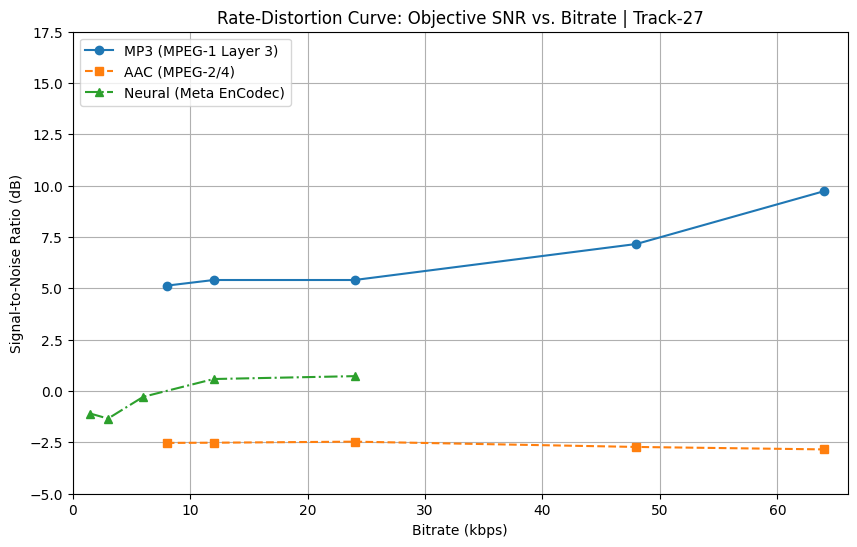

In [10]:
plot_rd_curve("source-audio/27.flac")


  SNR Results for Track-49
Bitrate      MP3 (dB)     AAC (dB)    
   8 kbps       10.72       -2.75
  12 kbps       10.90       -2.65
  24 kbps       10.90       -2.30
  48 kbps       12.01       -2.81
  64 kbps       14.48       -2.89

Bitrate      EnCodec (dB)
 1.5 kbps        4.23
   3 kbps        5.73
   6 kbps        7.15
  12 kbps        8.01
  24 kbps        8.30


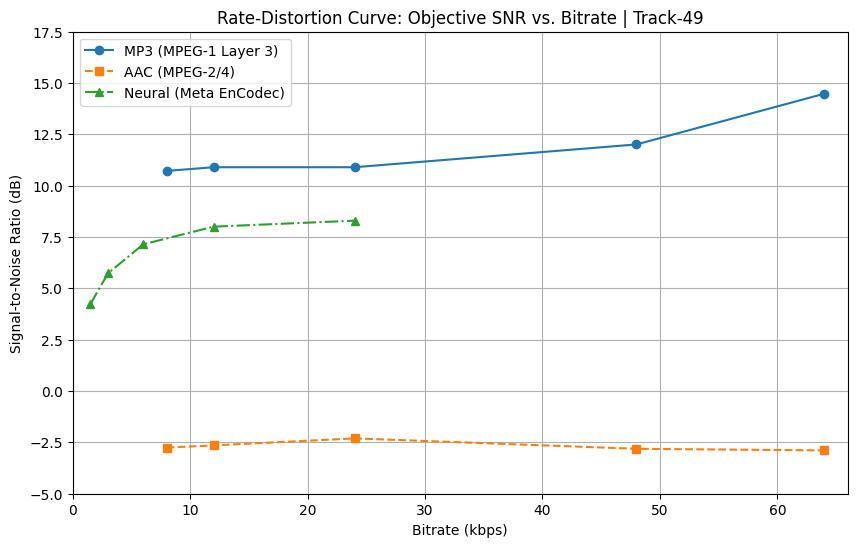

In [11]:
plot_rd_curve("source-audio/49.flac")


  SNR Results for Track-69
Bitrate      MP3 (dB)     AAC (dB)    
   8 kbps       11.05       -4.23
  12 kbps       11.97       -4.20
  24 kbps       11.97       -3.40
  48 kbps       14.95       -3.05
  64 kbps       16.55       -3.14

Bitrate      EnCodec (dB)
 1.5 kbps        1.10
   3 kbps        2.84
   6 kbps        5.09
  12 kbps        7.25
  24 kbps        8.24


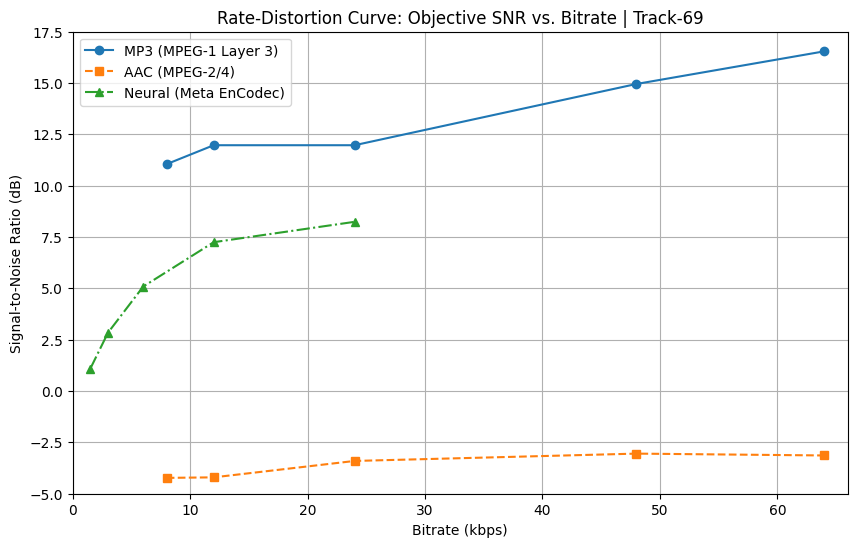

In [12]:
plot_rd_curve("source-audio/69.flac")

---

## Download Results
Run the cell below to zip all outputs for easy download from Colab.

In [13]:
import shutil

shutil.make_archive("export-output-psychoacoustic-vs-neural_audio_codecs", "zip", ".", "export-output")
print("Created export-output.zip -- download it from the file browser on the left.")

Created export-output.zip -- download it from the file browser on the left.
